In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import MINGLE as mg
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
file_path = r"/Volumes/data/MINGLE/Data/Esophagus/all_regions_from_h5mu.csv"
cells = mg.pp.read_file(file_path)

/opt/anaconda3/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
cells.obs

,patient,Sample_type,Path_report,neigh_name,neigh_sub,community,community common,Cell Type,Core Type,leiden,samplename,MS_CL,MS_CL_coarse,cellid,region,group,x,y
0,E08,Biopsy,Normal esophagus,Basal Squamous,Epithelial,Squamous,Squamous,Squamous Annexin A1+,Squamous,6,E08_reg003,SquamousEpi,SquamousEpi,15769_E08_reg003,E08_reg003,Normal esophagus,3797.0,2307.0
1,E08,Biopsy,Normal esophagus,Apical Squamous,Epithelial,Squamous,Squamous,Squamous Annexin A1+,Squamous,4,E08_reg003,SquamousEpi,SquamousEpi,15770_E08_reg003,E08_reg003,Normal esophagus,3781.0,2468.0
2,E08,Biopsy,Normal esophagus,Apical Squamous,Epithelial,Squamous,Squamous,Squamous Annexin A1+,Squamous,5,E08_reg003,SquamousEpi,SquamousEpi,15771_E08_reg003,E08_reg003,Normal esophagus,1623.0,2256.0
3,E08,Biopsy,Normal esophagus,Apical Squamous,Epithelial,Squamous,Squamous,Squamous p63+,Squamous,0,E08_reg003,SquamousEpi,SquamousEpi,15772_E08_reg003,E08_reg003,Normal esophagus,1525.0,1731.0
4,E08,Biopsy,Normal esophagus,Apical Squamous,Epithelial,Squamous,Squamous,Squamous p63+,Squamous,3,E08_reg003,SquamousEpi,SquamousEpi,15773_E08_reg003,E08_reg003,Normal esophagus,315.0,2527.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645656,E19,Resection,Normal esophagus,Basal Squamous,Epithelial,Squamous,Squamous,Squamous Annexin A1+,Adenocarcinoma,4,E19_reg003,SquamousEpi,SquamousEpi,686936_E19_reg003,E19_reg003,Normal esophagus,6775.0,4730.0
645657,E19,Resection,Normal esophagus,Apical Squamous,Epithelial,CK7hi and T cell,Mixed Epithelial,Squamous p63+,Adenocarcinoma,4,E19_reg003,SquamousEpi,SquamousEpi,686937_E19_reg003,E19_reg003,Normal esophagus,8636.0,3983.0
645658,E19,Resection,Normal esophagus,Specialized,Epithelial,Specialized c,Mixed Epithelial,Foveloar,Adenocarcinoma,14,E19_reg003,GastricEpi,GastricEpi,686938_E19_reg003,E19_reg003,Normal esophagus,7746.0,3637.0
645659,E19,Resection,Normal esophagus,Apical Squamous,Epithelial,Squamous,Squamous,Squamous Annexin A1+,Adenocarcinoma,4,E19_reg003,SquamousEpi,SquamousEpi,686939_E19_reg003,E19_reg003,Normal esophagus,6800.0,4836.0


In [7]:
cluster_col = "Cell Type"
neighborhood_col = "neigh_name"
region_key = "region"

In [8]:
centroids = mg.tl.centroid_Calculation(cells, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_col=region_key, k = 10)

Example dummy cols: ['Cell Type__B cell', 'Cell Type__CD4+ T cell', 'Cell Type__CD4+ T cell PD1+', 'Cell Type__CD4+ Treg', 'Cell Type__CD8+ T cell']


/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


{5:              x       y      region             Cell Type  B cell  CD4+ T cell  \
0       3797.0  2307.0  E08_reg003  Squamous Annexin A1+     0.0          0.0   
1       3781.0  2468.0  E08_reg003  Squamous Annexin A1+     0.0          0.0   
2       1623.0  2256.0  E08_reg003  Squamous Annexin A1+     0.0          0.0   
3       1525.0  1731.0  E08_reg003         Squamous p63+     0.0          0.0   
4        315.0  2527.0  E08_reg003         Squamous p63+     0.0          0.0   
...        ...     ...         ...                   ...     ...          ...   
645656  6775.0  4730.0  E19_reg003  Squamous Annexin A1+     0.0          0.0   
645657  8636.0  3983.0  E19_reg003         Squamous p63+     0.0          0.0   
645658  7746.0  3637.0  E19_reg003              Foveloar     0.0          0.0   
645659  6800.0  4836.0  E19_reg003  Squamous Annexin A1+     0.0          0.0   
645660  6167.0  3677.0  E19_reg003  Squamous Annexin A1+     0.0          0.0   

        CD4+ T cell PD1

In [9]:
mg.tl.cpu_gmm_probability(CELLS_ADATA=cells, CENTROIDS_ADATA=centroids, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_key=region_key, k = 100)

Example dummy cols: ['Cell Type__B cell', 'Cell Type__CD4+ T cell', 'Cell Type__CD4+ T cell PD1+', 'Cell Type__CD4+ Treg', 'Cell Type__CD8+ T cell']
Using 14 processes.


/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprec

AnnData object with n_obs × n_vars = 645661 × 0
    obs: 'patient', 'Sample_type', 'Path_report', 'neigh_name', 'neigh_sub', 'community', 'community common', 'Cell Type', 'Core Type', 'leiden', 'samplename', 'MS_CL', 'MS_CL_coarse', 'cellid', 'region', 'group', 'x', 'y'
    uns: 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

Example dummy cols: ['Cell Type__B cell', 'Cell Type__CD4+ T cell', 'Cell Type__CD4+ T cell PD1+', 'Cell Type__CD4+ Treg', 'Cell Type__CD8+ T cell']


Running KMeans + MINGLE (CPU):  64%|██████▍   | 32/50 [01:45<01:32,  5.15s/it]/Users/jamesw/Desktop/Mingle/src/MINGLE/tl/n_neighbors.py:127: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  per_cell_df[cluster_col] = labels
Running KMeans + MINGLE (CPU):  66%|██████▌   | 33/50 [01:50<01:29,  5.29s/it]/Users/jamesw/Desktop/Mingle/src/MINGLE/tl/n_neighbors.py:125: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  per_cell_df[f"log_likelihood_n{n}"] = log_likelihoods
/Users/jamesw/Desktop/Mingle/src/MINGLE/tl/n_neighbors.py:126: Performan

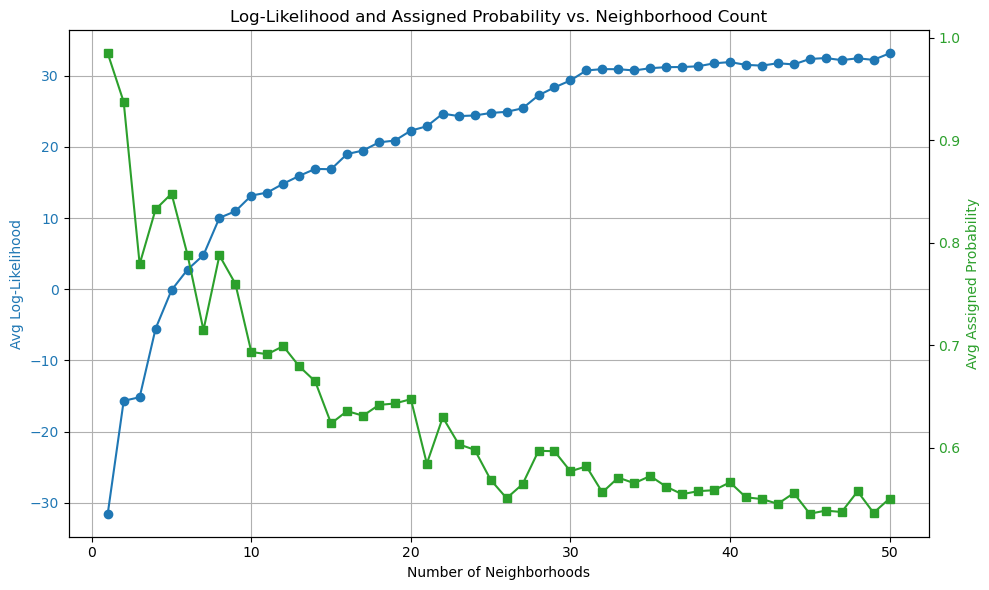

📍 Best plateau starts at n = 7 (score = 0.5642)


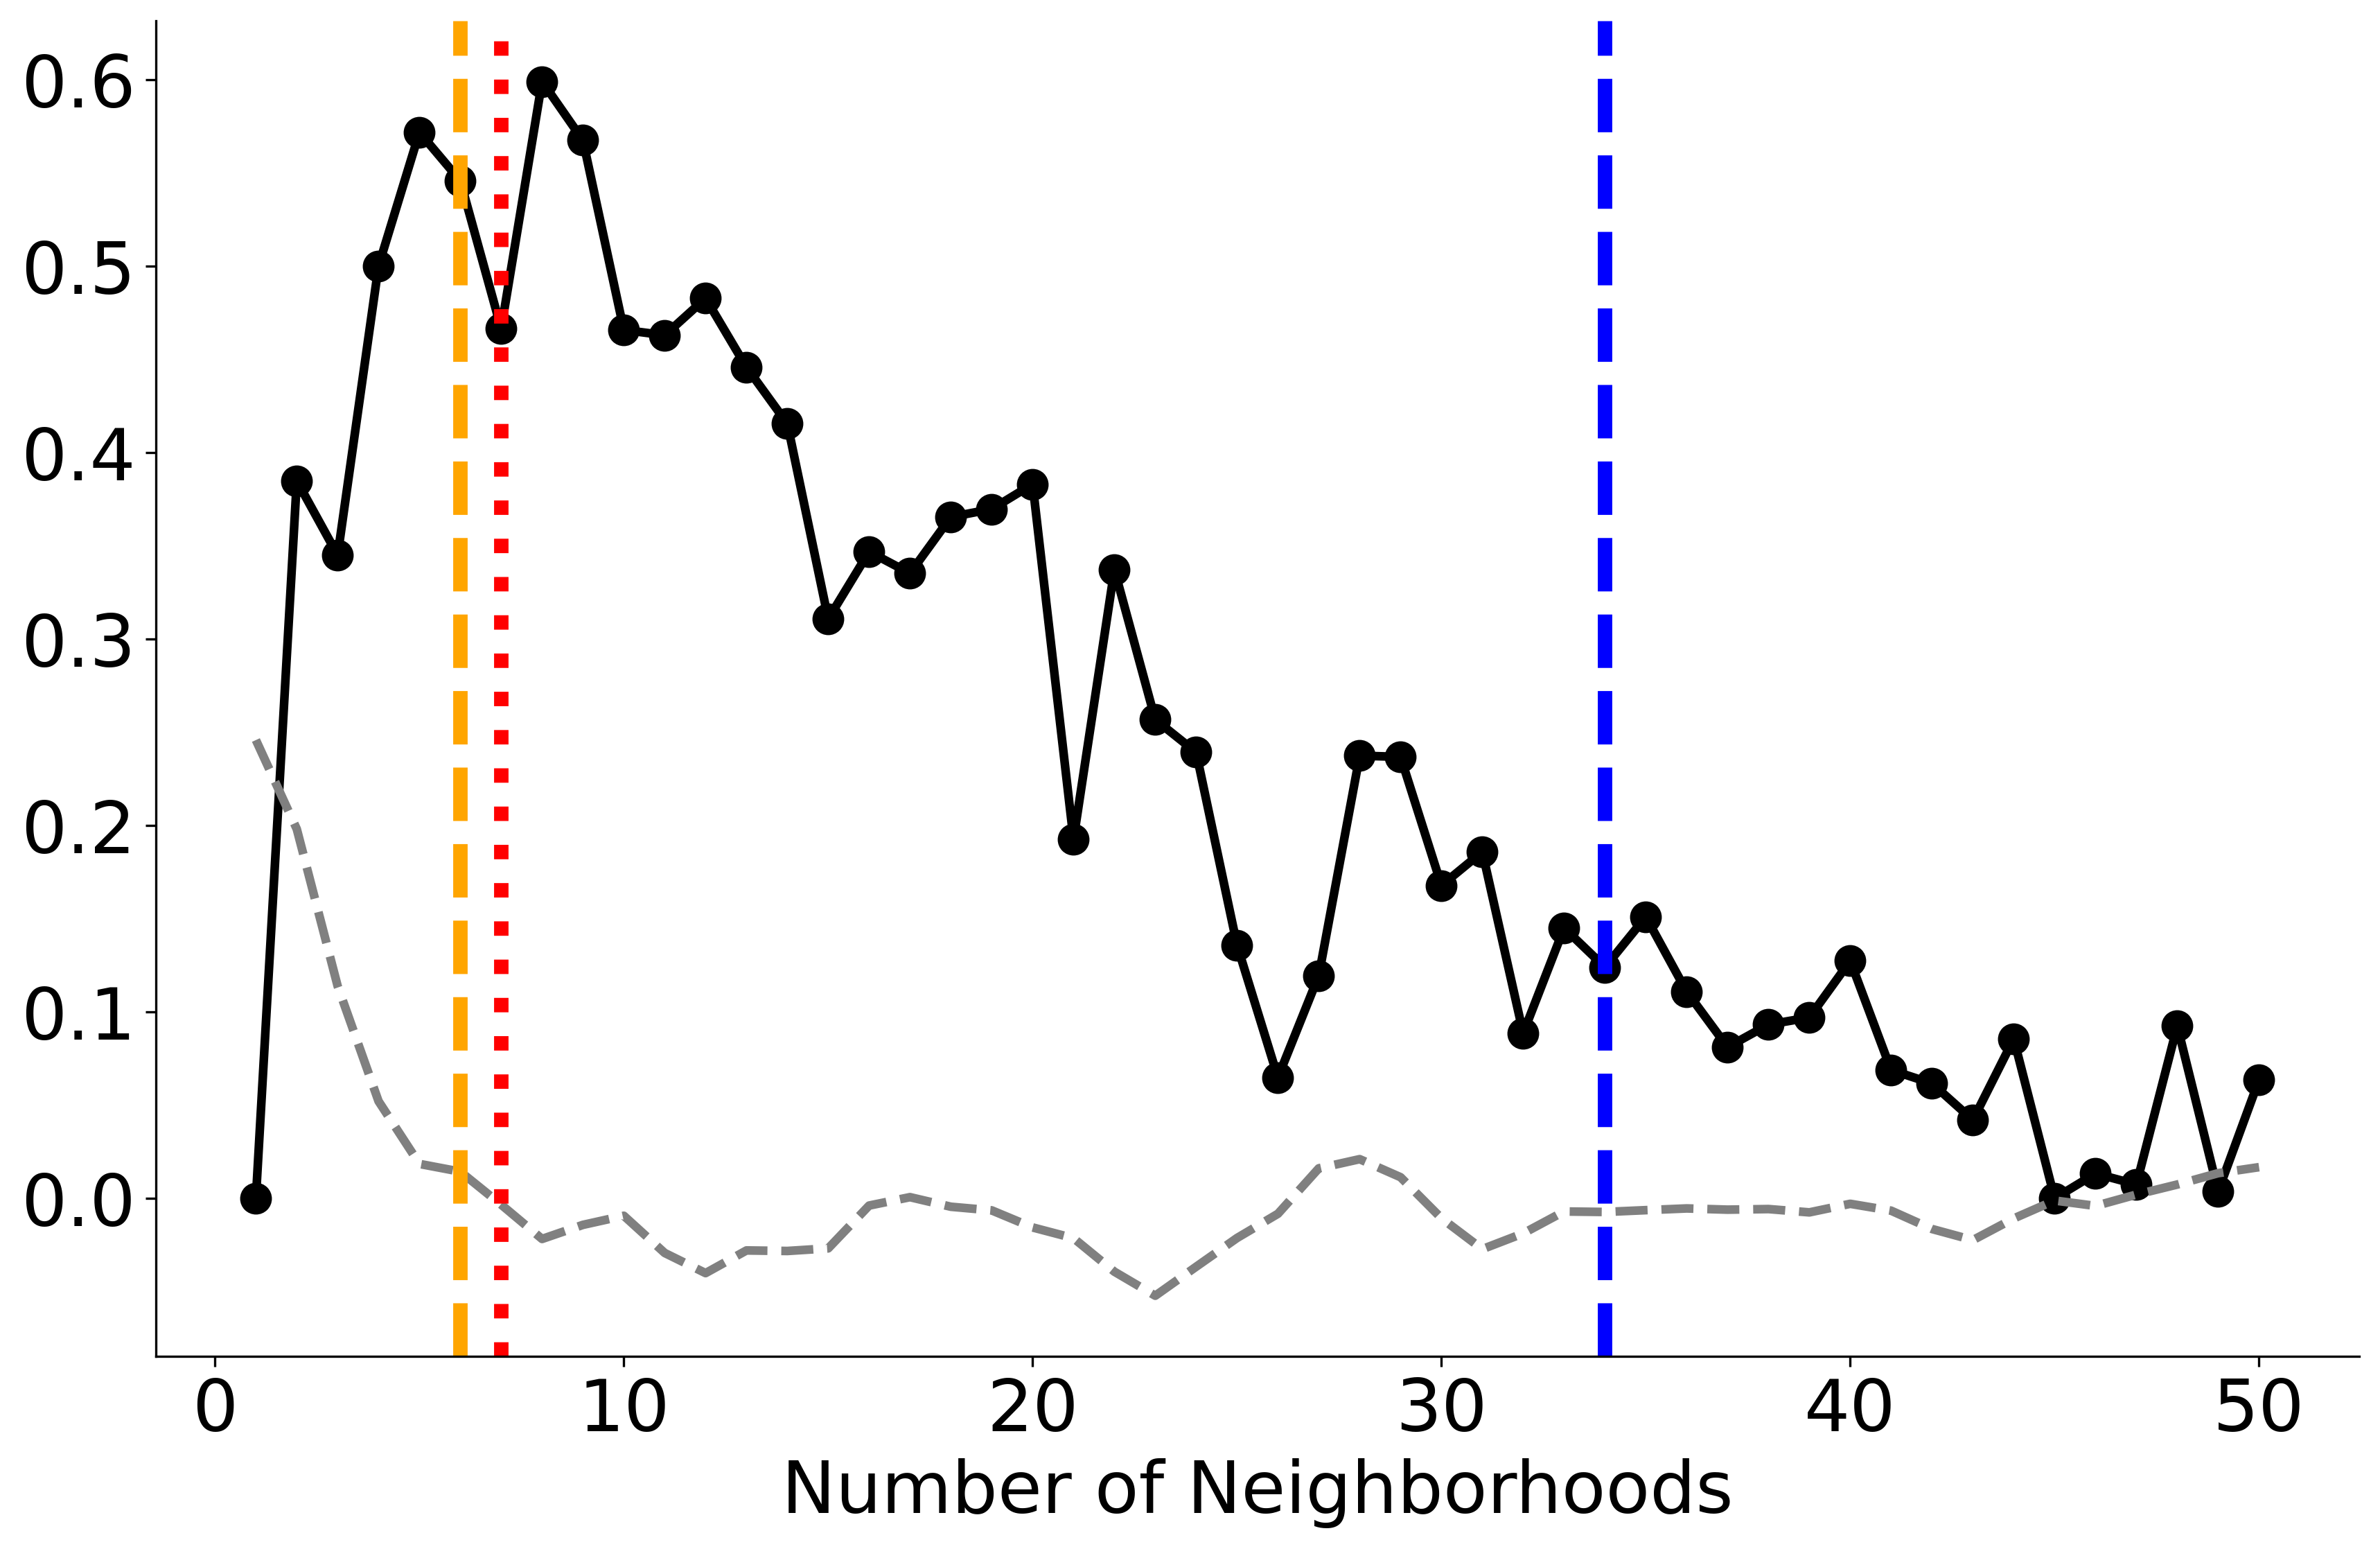

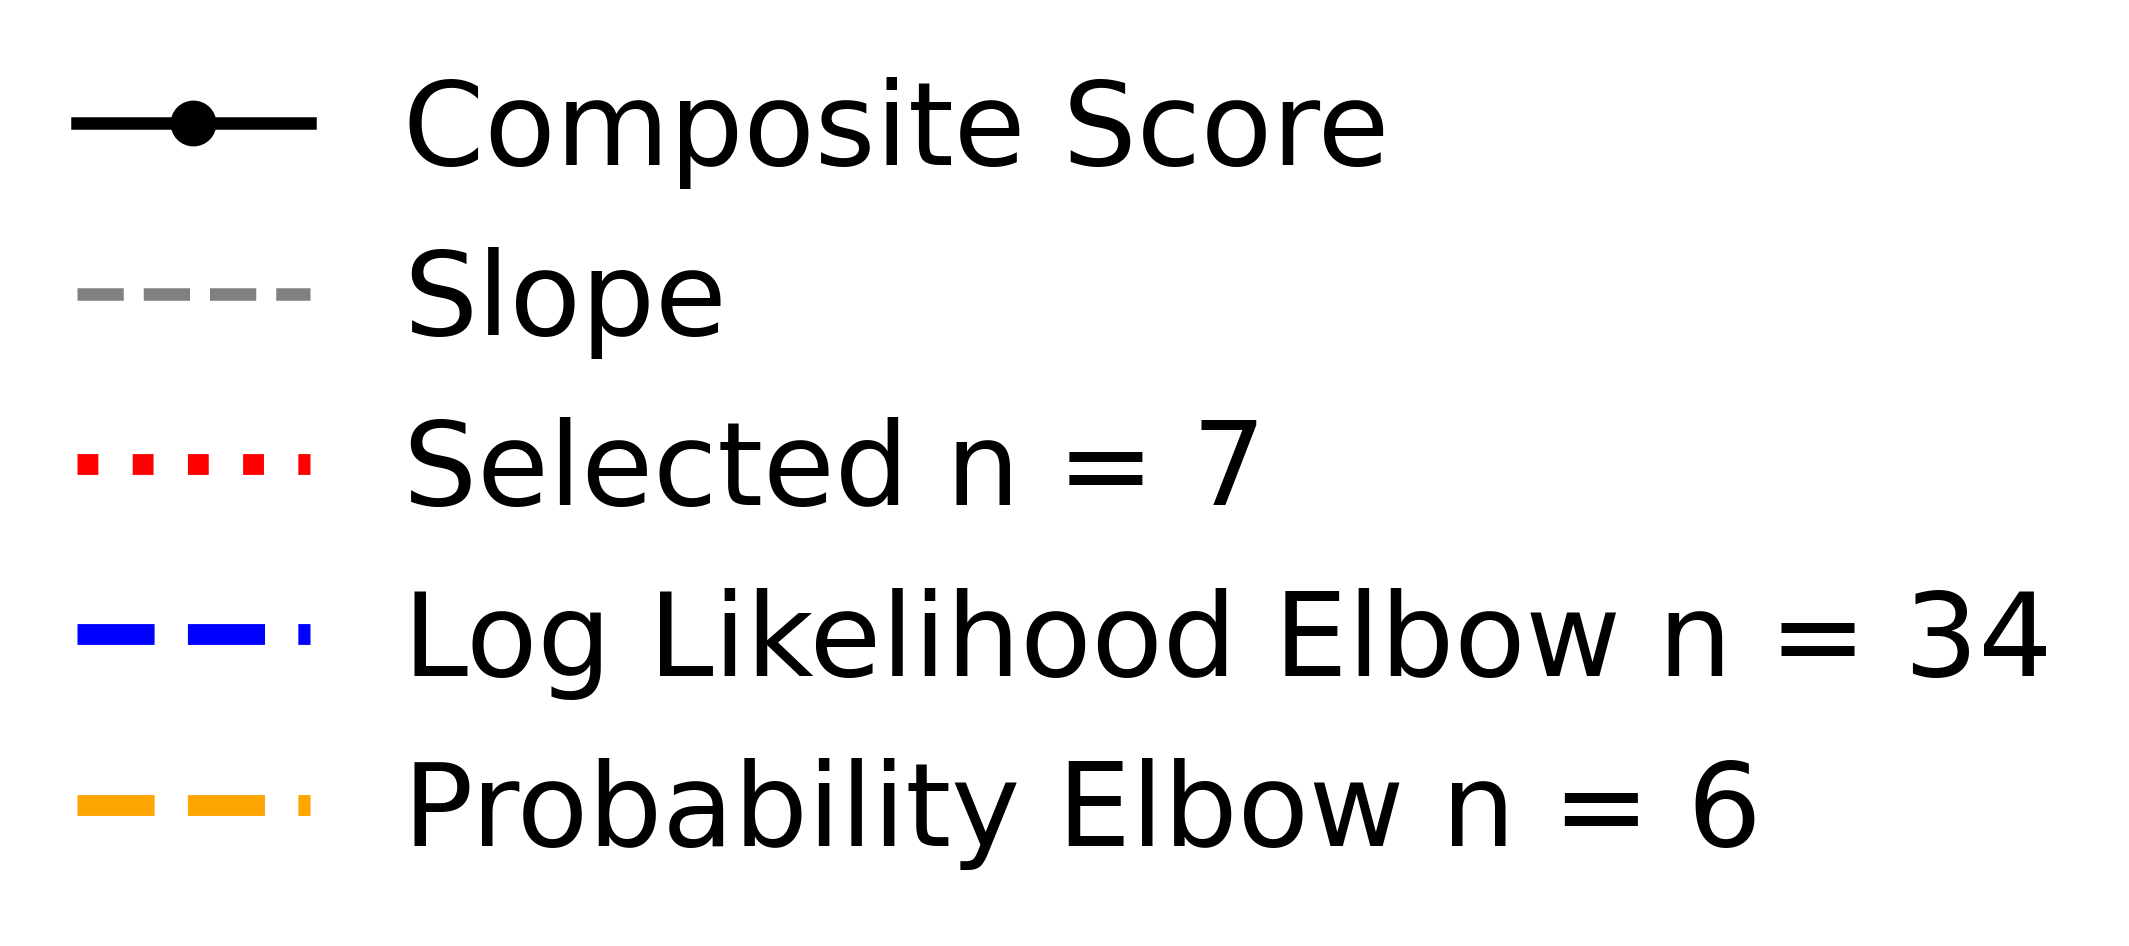

   rank  start_n  length  mean_score  mean_slope  start_idx
0     1        7       4    0.533551    0.012197          6


In [12]:
X = "x"
Y = "y"
sum_cols = list(cells.obs[cluster_col].unique())
keep_cols = [X, Y, region_key, cluster_col]

windows = mg.tl.KNN2(cells, cluster_col=cluster_col, region_key=region_key, keep_obs_cols=keep_cols)
k = 10
windows2 = windows[k]
windows2[cluster_col] = cells.obs[cluster_col].values

adata_windows = ad.AnnData(X=None, obs=windows2.copy())
adata_windows.obs_names = adata_windows.obs.index.astype(str)

adata_windows.obsm[f"knn_windows_k{k}"] = adata_windows.obs[sum_cols].astype("float32").values
adata_windows.uns["knn_windows"] = {
    "k": k,
    "cols": list(sum_cols),
    "source": "dummy-count neighborhood windows",
}

summary_df, per_cell_df = mg.tl.run_mingle_over_n_clusters(
    adata=adata_windows,        
    knn_feature_cols=sum_cols,   
    n_range=range(1, 51),
    return_per_cell=True,
    plot_summary=True,
    x_key="x",
    y_key="y",
    region_key="region",
)

ll_idx, ll_n, _ = mg.tl.find_elbow_point(
    y_values=None,
    x_values=None,
    adata=adata_windows,
    uns_key="mingle_n_clusters",
    y_key="avg_log_likelihood",
    x_key="n_clusters",
)

prob_idx, prob_n, _ = mg.tl.find_elbow_point(
    y_values=None,
    x_values=None,
    adata=adata_windows,
    uns_key="mingle_n_clusters",
    y_key="avg_assigned_probability",
    x_key="n_clusters",
)

# Step 2: Constrained plateau search (pulled from adata.uns)
composite_df, best_n, ranked_plateaus = mg.tl.find_best_unsupervised_plateau(
    log_likelihoods=None,
    assigned_probs=None,
    elbow_min=min(ll_n, prob_n),
    elbow_max=max(ll_n, prob_n),
    adata=adata_windows,
    uns_key="mingle_n_clusters",
    ll_key="avg_log_likelihood",
    prob_key="avg_assigned_probability",
    out_uns_key="mingle_plateau_selection",  # optional; remove if you don't want storage
)

# Step 3: Plot (unchanged)
mg.tl.plot_stable_composite(composite_df, best_n, ll_n, prob_n)

# Step 4: View ranked plateau table
print(ranked_plateaus)